In [3]:
# # !pip install kaleido
# import pandas as pd
# import kaleido
# import plotly
# import plotly.express as px
# import numpy as np
# # import plotly.io as pio
# # pio.renderers.default = 'svg'
# import plotly.io as pio
# pio.renderers.default='notebook'


# import plotly.graph_objs as go
# from plotly.subplots import make_subplots

import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np 
import pandas as pd
%matplotlib inline
plt.style.use('default')


churn_data = pd.read_csv('data/churn.csv')
churn_data.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Столбцы таблицы:

RowNumber — номер строки таблицы (это лишняя информация, поэтому можете сразу от неё избавиться)
CustomerId — идентификатор клиента
Surname — фамилия клиента
CreditScore — кредитный рейтинг клиента (чем он выше, тем больше клиент брал кредитов и возвращал их)
Geography — страна клиента (банк международный)
Gender — пол клиента
Age — возраст клиента
Tenure — сколько лет клиент пользуется услугами банка
Balance — баланс на счетах клиента в банке
NumOfProducts — количество услуг банка, которые приобрёл клиент
HasCrCard — есть ли у клиента кредитная карта (1 — да, 0 — нет)
IsActiveMember — есть ли у клиента статус активного клиента банка (1 — да, 0 — нет)
EstimatedSalary — предполагаемая заработная плата клиента
Exited — статус лояльности (1 — ушедший клиент, 0 — лояльный клиент)

In [4]:
churn_data = churn_data.drop('RowNumber', axis=1)
display(churn_data)


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


9.1. Каково соотношение ушедших и лояльных клиентов? Покажите это на графике и дайте комментарий по соотношению.

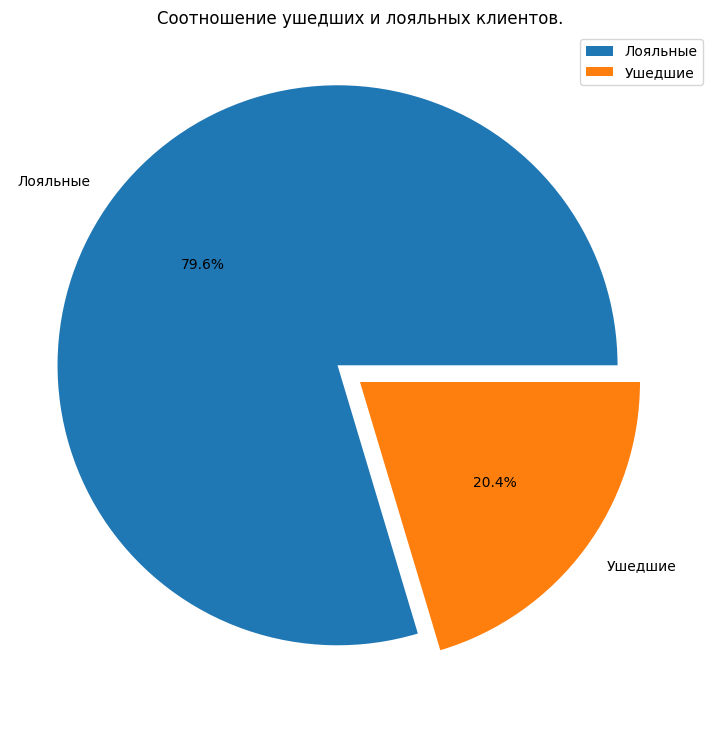

In [60]:
churn_data['type_client'] = np.where(churn_data['Exited'] == 1, 'Ушедшие', 'Лояльные')

pie_chart = churn_data.groupby(['type_client'])['CustomerId'].count().copy()
# display(pie_chart.head)
# labels = ['Лояльные', 'Ушедшие']
fig = plt.figure(figsize=(10, 7))
axes = fig.add_axes([0, 0, 1, 1])
plt.title('Cоотношение ушедших и лояльных клиентов.')

axes.pie(pie_chart, 
         explode = [0.1, 0],
         labels = pie_chart.index, 
         autopct='%.1f%%'
         )
axes.legend();
# axes.show()

# pie_chart = churn_data[['type_client','Exited']].copy()
# pie_chart = churn_data.groupby(by='type_client', as_index=False)['Exited'].count()
# type_client_sum = pie_chart['Exited'].sum()
# pie_chart['type_client_per'] = round((pie_chart['Exited'] * 100) / type_client_sum)
# fig = px.pie(pie_chart, 
#              values="type_client_per", 
#              names="type_client",
#              width=700, height=700,
#              color='type_client',
#              color_discrete_map={"Лояльные": "lightgreen", "Ушедшие": "lightback"}
#              )
# fig.update_layout(title_text='Cоотношение ушедших и лояльных клиентов.', title_x=0.5)
# fig.show()


Клиенты в подовляющем большинстве(80%) лояльны к банку. Банк осуществляет эффективную деятельность по работе с клиентами, но необходимо обратить внимание на значительный отток клиентов и принять меры по уменьшению оттока клиентов. Банк в целом стабильный, но необходимо понять причины оттока клиентов.

9.2. Постройте график, показывающий распределение баланса пользователей, у которых на счету больше 2 500 долларов. Опишите распределение и сделайте выводы.

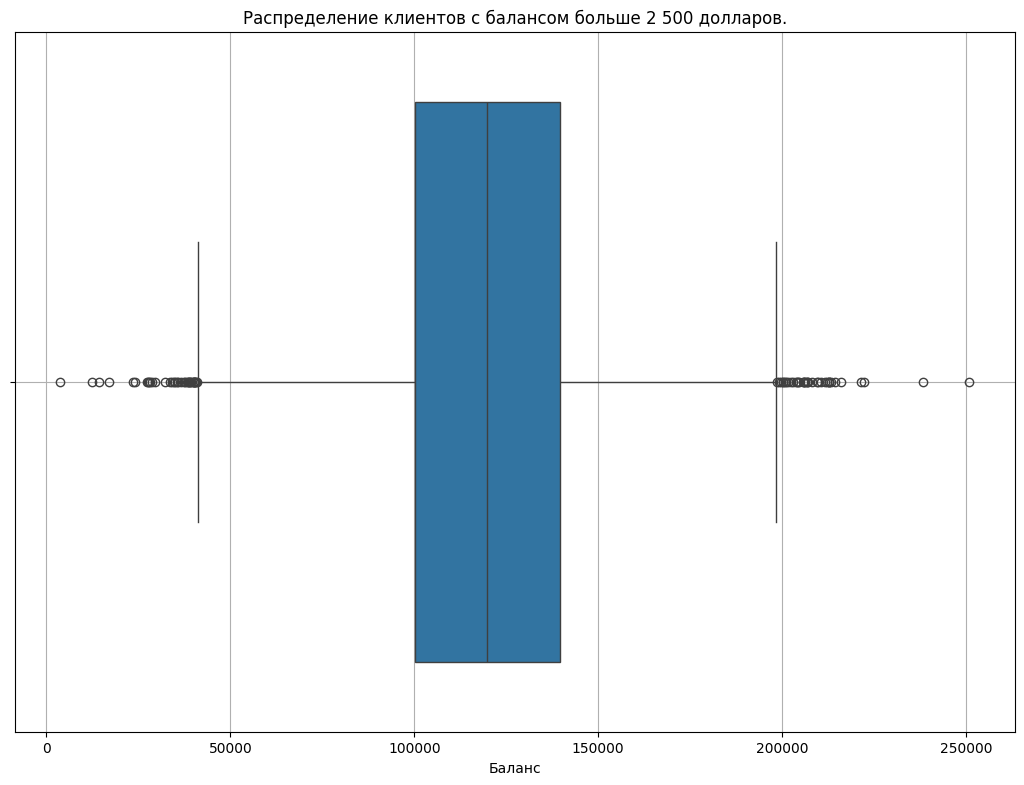

In [61]:
# boxplot_chart = churn_data[(churn_data['Balance'] > 2500)] ['Balance'].copy()
# boxplot_chart = churn_data[(churn_data['Balance'] > 2500)].copy()
boxplot_chart = churn_data.loc[churn_data['Balance'] > 2500, ['Balance']].copy()
# display(type(boxplot_chart))
# avg_temp_df = pd.DataFrame({'Balance': boxplot_chart})
fig = plt.figure(figsize=(10, 7))
axes = fig.add_axes([0, 0, 1, 1])
# fig = plt.figure(figsize=(10, 7))
fig = sns.boxplot(
    data = boxplot_chart,  
    x = "Balance"
)
fig.set_title('Распределение клиентов с балансом больше 2 500 долларов.')
fig.set_xlabel('Баланс')
fig.grid();
# display(boxplot_chart.describe())
# plt.show();
# fig = px.box(data_frame=boxplot_chart, x = "Balance")
# fig.update_layout(title_text='Распределение клиентов с балансом больше 2 500 долларов.', title_x=0.5)
# # fig.update_layout(set_ylabel='Клиенты (активные и выбывшие).')
# # fig.set_title('Распределение по балансам клиентов с балансом > 2500')
# # fig.set_ylabel('Клиенты (активные и выбывшие)')
# fig.show()


Из графика видим, клиенты распределены приблизительно от 40 до 198 тысяч долларов. Медианный баланс приблизительно 120 тысяч долларов, максимальное распределение клиентов в отрезке от 100.2 (25% квантиль) до 140 (75% квантиль) тысяч долларов. Выбросы слева и справа примерно одинаковой ширины. Наиболее выгодные условия для клиентов по хранению средств на балансе в банке находятся в интервале от 100 до 140 тысяч долларов.

9.3. Посмотрите на распределение баланса клиента в разрезе признака оттока. Как различаются суммы на накопительном счёте ушедших и лояльных клиентов? Подумайте и напишите, с чем это может быть связано, что может не устраивать ушедших клиентов в банке.

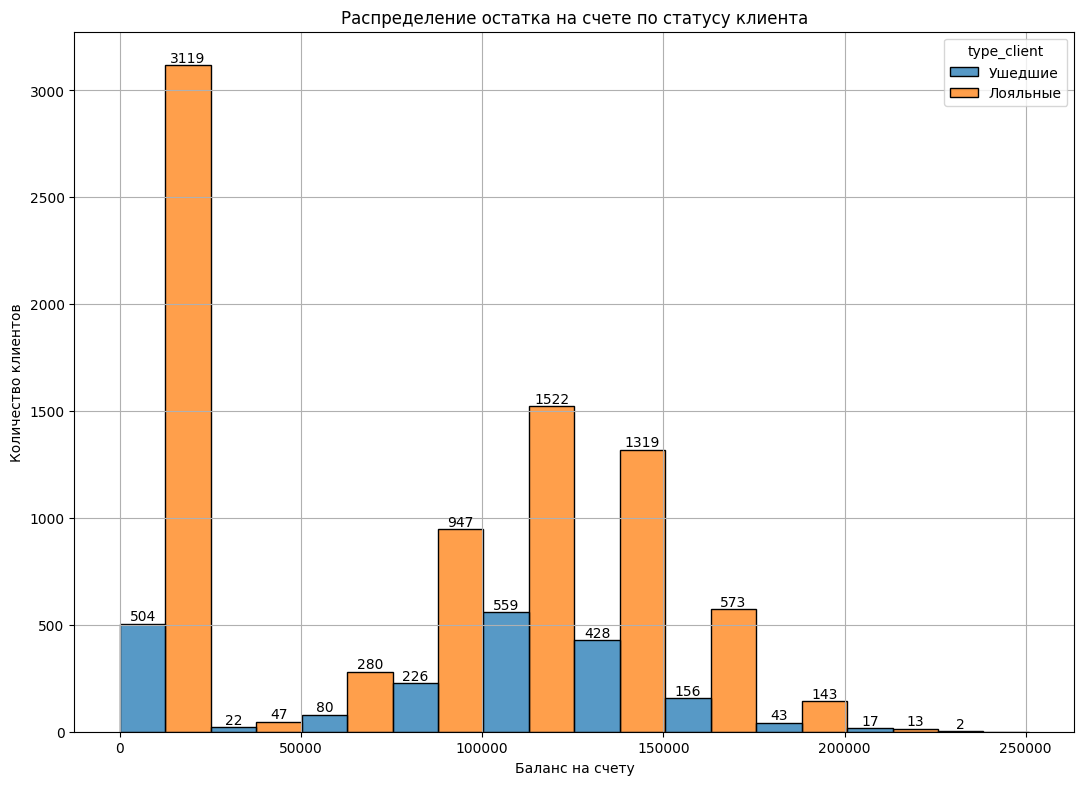

In [63]:

# mean_balance_1 = churn_data.groupby(['Balance','type_client'], as_index = False) ['Balance'].mean().copy()
# display(type(mean_balance_1))

# mean_balance_2 = churn_data.loc[churn_data['Exited'] == 1, ['type_client','Balance']].copy()
# display(mean_balance_2.count())
# display(mean_balance_2.describe())
# mean_balance_2 = churn_data.groupby(['type_client'], as_index = False) ['Balance'].sum()
# display(mean_balance_2.describe())
# display(mean_balance_2)
fig = plt.figure(figsize=(10, 7))
axes = fig.add_axes([0, 0, 1, 1])
fig = sns.histplot(data=churn_data, x='Balance', hue='type_client', multiple="dodge", bins=10)
# plt.text(x=20, y=5, s="Highest tip", fontsize=12, color='red')
for p in fig.patches:
    height = p.get_height()
    if height > 0:  # Avoid labeling empty bins
        fig.text(x = p.get_x() + (p.get_width() / 2), # Centered on bar
                y = height + 0.5,                    # Slightly above bar
                s = f'{int(height)}',                # The label text
                ha = 'center', va = 'bottom')

plt.title("Распределение остатка на счете по статусу клиента")
plt.xlabel("Баланс на счету")
plt.ylabel("Количество клиентов")
fig.grid()



# # Разделение данных по признаку Churn
# loyal_customers = churn_data[churn_data['Exited'] == 0 ]['Balance']
# churned_customers = churn_data[churn_data['Exited'] == 1 ]['Balance']

# # Создание графика
# plt.figure(figsize=(10, 6))

# # Гистограмма для Loyal customers
# n_loyal, bins_loyal, patches_loyal = plt.hist(loyal_customers, bins=30, alpha=0.5, label='Loyal', color='blue')
# for i in range(len(bins_loyal)-1):
#     plt.text((bins_loyal[i]+bins_loyal[i+1])/2, n_loyal[i], f"{int(n_loyal[i])}", ha="center", va="bottom")

# # Гистограмма для Churned customers
# n_churned, bins_churned, patches_churned = plt.hist(churned_customers, bins=bins_loyal, alpha=0.5, label='Churned', color='orange')
# for i in range(len(bins_churned)-1):
#     plt.text((bins_churned[i]+bins_churned[i+1])/2, n_churned[i], f"{int(n_churned[i])}", ha="center", va="top")

# # Оформление графика
# plt.title('Распределение баланса клиентов по признаку оттока')
# plt.xlabel('Баланс на счете ($)')
# plt.ylabel('Количество клиентов')
# plt.legend()
# plt.grid(True)
# plt.show()

# fig = plt.figure(figsize=(10, 7))
# # fig, ax = plt.subplots(figsize=(20, 8))
# fig = sns.histplot(data=mean_balance_1, x="Balance", binwidth=10000, hue="type_client")
# # fig = sns.histplot(
# #     data = mean_balance_1, 
# #     x='Balance',
# #     #bins = 100,
# #     kde = True,
# #     hue='type_client',
# #     bins=20,
# # )
# # for p in ax.patches:
# #     ax.annotate(
# #         format(round(p.get_height()), '.0f'),
# #         (p.get_x() + p.get_width() / 2., p.get_height()),
# #         ha='center', va='center',
# #         size=14,
# #         xytext=(0, 9),
# #         textcoords='offset points'
# #     )
# # fig.set_title( 'Распределение баланса клиентов: 1 - ушедших, 0 - лояльных', size=18 )
# # fig.set_xlabel('Баланс, $', size=18) 
# # fig.set_ylabel('Количество клиентов', size=18) 

# #fig1.write_image('data/image3.png')
# fig.grid();

# chart_df = churn_data[['Balance','Exited']].copy()
# chart_1 = chart_df.groupby( 'Balance', as_index = False )['Exited'].mean().round(2) 
# display(churn_data)

# mean_balance_1 = churn_data.groupby(['type_client'], as_index = False)['Balance'].mean().copy()
# display(mean_balance_1)
# mean_balance = churn_data.groupby(['Balance','type_client'], as_index = False)['Exited'].mean().copy()




# fig = px.histogram(mean_balance, x='Balance', color='type_client',  nbins=30,
#                   title='Гистограмма распределения баланса клиентов по признаку оттока',
#                   labels={'Balance':'Сумма на накопительном счете', 'type_client':'Тип клиента'},
#                   histnorm='probability density',
#                   barmode = 'overlay',
#                   opacity=0.7)

# # Настраиваем легенду и оформление
# fig.update_layout(showlegend=True)
# fig.update_xaxes(title_text='Сумма на накопительном счете')
# fig.update_yaxes(title_text='Частота')

# fig.show()
# print(mean_balance_by_churn)

# chart_1["Status"] = (chart_1["Exited"] * 100).astype(int)

# display(mean_balance)

Интерпретация графика
После построения графика мы можем заметить различия в распределениях:

Лояльные клиенты: Их средний остаток на счете может быть выше, поскольку они остаются клиентами банка дольше и имеют больше возможностей накапливать средства.
Ушли клиенты: У ушедших клиентов часто наблюдается меньший остаток на счете. Это может говорить о недостаточной удовлетворенности услугой накопления или инвестициями в банке.
Причины возможного недовольства:
Вот некоторые гипотезы относительно того, почему сумма на накопительных счетах ушедших клиентов ниже:

Высокие комиссии:Возможно, банк взимал высокие комиссии за обслуживание счетов или операции, что снижало привлекательность хранения денег в данном банке.
Низкий процент по вкладам:Если проценты по депозитам были низкими, клиенты могли искать альтернативные варианты размещения капитала с большей доходностью.
Отсутствие удобных онлайн-сервисов:Современные потребители ожидают удобства и простоты управления своими финансами через мобильные приложения и веб-интерфейсы. Отсутствие таких инструментов могло привести к уходу клиентов.
Качество обслуживания:Низкое качество клиентского сервиса также могло повлиять на решение покинуть банк. Например, длительные ожидания решения вопросов или проблемы с технической поддержкой могли стать причиной отказа от услуг банка.
Конкуренция банков:Клиенты могли перейти в конкурирующие банки, предложившие лучшие условия по кредитам, картам или другим продуктам.
Таким образом, на основании проведенного анализа мы видим разницу в суммах на накопительных счетах оставшихся и ушедших клиентов. Причинами могут служить неудовлетворенность услугами банка, неудобством интерфейсов или условиями вкладов. Чтобы сохранить лояльность клиентов, банку рекомендуется провести дополнительное исследование факторов оттока и предпринять меры по улучшению качества обслуживания и продуктов.